In [2]:
# SIRYA: metti entrambi a True se sei su colab
COLAB = False
SIRYA = False

if COLAB:

    from google.colab import drive
    drive.mount('/content/drive', force_remount=True)

    !rm -rf LCTSCProject2024
    !git clone https://github.com/AI-For-Experimental-And-Applied-Physics/LCTSCProject2024.git
    !pip install itkwidgets
    !pip install -r LCTSCProject2024/requirements.txt

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import pydicom
import os

from ipywidgets import interact, IntSlider, FloatSlider
import itkwidgets as viewer

In [4]:
if SIRYA:
    data_base_dir = '/content/drive/MyDrive/Colab Notebooks/Biomedical Imaging/DATA'
    data_csv = '/content/drive/MyDrive/Colab Notebooks/Biomedical Imaging/DATA/lctsc_metadata.csv'
else:
    data_base_dir = './'
    data_csv = './lctsc_metadata.csv'

## Exploring the Dataset Structure and Metadata

Let's start by exploring the directory structure and reading the metadata from the DICOM files.

In [5]:
# Load the metadata.csv file
metadata_df = pd.read_csv(data_csv)

# Display the first few rows and column information
print(metadata_df.head())
print(metadata_df.info())

                                          Series UID Collection  \
0  1.3.6.1.4.1.14519.5.2.1.7014.4598.280355341349...      LCTSC   
1  1.3.6.1.4.1.14519.5.2.1.7014.4598.110977663386...      LCTSC   
2  1.3.6.1.4.1.14519.5.2.1.7014.4598.106943890850...      LCTSC   
3  1.3.6.1.4.1.14519.5.2.1.7014.4598.578895540487...      LCTSC   
4  1.3.6.1.4.1.14519.5.2.1.7014.4598.941697026234...      LCTSC   

   3rd Party Analysis                           Data Description URI  \
0                 NaN  https://doi.org/10.7937/K9/TCIA.2017.3r3fvz08   
1                 NaN  https://doi.org/10.7937/K9/TCIA.2017.3r3fvz08   
2                 NaN  https://doi.org/10.7937/K9/TCIA.2017.3r3fvz08   
3                 NaN  https://doi.org/10.7937/K9/TCIA.2017.3r3fvz08   
4                 NaN  https://doi.org/10.7937/K9/TCIA.2017.3r3fvz08   

          Subject ID                                          Study UID  \
0  LCTSC-Test-S1-101  1.3.6.1.4.1.14519.5.2.1.7014.4598.492964872630...   
1  LCTSC-Test-

In [6]:
# fill the patient dict variable
patient_dict = {}

# Method 2: Using itertuples() (More efficient than iterrows())
for row in metadata_df.itertuples():
  patient_id = getattr(row, '_5') # unique Name
  file_type = getattr(row, 'Modality') # check if RTSTRUCT or CT
  file_location = getattr(row, '_16') # Path to the images
  if patient_id in patient_dict.keys() :
    patient_dict[patient_id][file_type] = file_location
  else:
    patient_dict[patient_id] = {}
    patient_dict[patient_id][file_type] = file_location

print(patient_dict)

{'LCTSC-Test-S1-101': {'RTSTRUCT': './LCTSC/LCTSC-Test-S1-101/1.3.6.1.4.1.14519.5.2.1.7014.4598.492964872630309412859177308186/1.3.6.1.4.1.14519.5.2.1.7014.4598.280355341349691222365783556597', 'CT': './LCTSC/LCTSC-Test-S1-101/1.3.6.1.4.1.14519.5.2.1.7014.4598.492964872630309412859177308186/1.3.6.1.4.1.14519.5.2.1.7014.4598.106943890850011666503487579262'}, 'LCTSC-Test-S1-102': {'RTSTRUCT': './LCTSC/LCTSC-Test-S1-102/1.3.6.1.4.1.14519.5.2.1.7014.4598.238478060677653494401819620444/1.3.6.1.4.1.14519.5.2.1.7014.4598.110977663386843546355807661874', 'CT': './LCTSC/LCTSC-Test-S1-102/1.3.6.1.4.1.14519.5.2.1.7014.4598.238478060677653494401819620444/1.3.6.1.4.1.14519.5.2.1.7014.4598.639871532605224417554459681163'}, 'LCTSC-Test-S1-103': {'CT': './LCTSC/LCTSC-Test-S1-103/1.3.6.1.4.1.14519.5.2.1.7014.4598.816327386653410772475068003264/1.3.6.1.4.1.14519.5.2.1.7014.4598.578895540487402949445746417374', 'RTSTRUCT': './LCTSC/LCTSC-Test-S1-103/1.3.6.1.4.1.14519.5.2.1.7014.4598.816327386653410772475

In [7]:
def load_patient_dicom_files(patient_dir):
    """Loads all DICOM files from a patient directory, sorted by slice position."""
    dicom_files = []
    for filename in os.listdir(patient_dir):
        if filename.endswith('.dcm'):
            file_path = os.path.join(patient_dir, filename)
            try:
                dicom_files.append(pydicom.dcmread(file_path))
            except Exception as e:
                print(f"Error reading {file_path}: {e}")
    
    # Sort by ImagePositionPatient[2] (z-coordinate) for correct anatomical order
    dicom_files.sort(key=lambda x: float(x.ImagePositionPatient[2]) if 'ImagePositionPatient' in x else 0)
    
    return dicom_files

def get_patient_metadata(dicom_files):
    """Extracts relevant metadata from a list of DICOM files for a patient."""
    if not dicom_files:
        return None
    metadata = {
        'PatientID': dicom_files[0].PatientID if 'PatientID' in dicom_files[0] else None,
        'PatientSex': dicom_files[0].PatientSex if 'PatientSex' in dicom_files[0] else None,
        'PatientAge': dicom_files[0].PatientAge if 'PatientAge' in dicom_files[0] else None,
        'StudyDate': dicom_files[0].StudyDate if 'StudyDate' in dicom_files[0] else None,
        'SeriesDescription': dicom_files[0].SeriesDescription if 'SeriesDescription' in dicom_files[0] else None,
        'NumberOfSlices': len(dicom_files),
        # Add more relevant metadata as needed
    }
    return metadata

# Iterate through the patient directories and collect metadata
all_metadata = []

for k,v in patient_dict.items():
  if v['CT']:
    dicom_files = load_patient_dicom_files(os.path.join(data_base_dir,v['CT'].replace('./','')))
    if dicom_files:
        print(f"Patient ID: {k}, Number of DICOM files: {len(dicom_files)}")
        metadata = get_patient_metadata(dicom_files)
        all_metadata.append(metadata)

# Create a Pandas DataFrame from the collected metadata
metadata_df = pd.DataFrame(all_metadata)

# Display the first few rows of the metadata DataFrame
print("First few rows of the metadata DataFrame:")
print(metadata_df.head())

# Basic statistics of the metadata
print("\nBasic statistics of the metadata:")
print(metadata_df.describe(include='all'))

Patient ID: LCTSC-Test-S1-101, Number of DICOM files: 130
Patient ID: LCTSC-Test-S1-102, Number of DICOM files: 148
Patient ID: LCTSC-Test-S1-103, Number of DICOM files: 152
Patient ID: LCTSC-Test-S1-104, Number of DICOM files: 131
Patient ID: LCTSC-Test-S1-201, Number of DICOM files: 117
Patient ID: LCTSC-Test-S1-202, Number of DICOM files: 131
Patient ID: LCTSC-Test-S1-203, Number of DICOM files: 153
Patient ID: LCTSC-Test-S1-204, Number of DICOM files: 138
Patient ID: LCTSC-Test-S2-101, Number of DICOM files: 160
Patient ID: LCTSC-Test-S2-102, Number of DICOM files: 176
Patient ID: LCTSC-Test-S2-103, Number of DICOM files: 120
Patient ID: LCTSC-Test-S2-104, Number of DICOM files: 144
Patient ID: LCTSC-Test-S2-201, Number of DICOM files: 136
Patient ID: LCTSC-Test-S2-202, Number of DICOM files: 142
Patient ID: LCTSC-Test-S2-203, Number of DICOM files: 136
Patient ID: LCTSC-Test-S2-204, Number of DICOM files: 176
Patient ID: LCTSC-Test-S3-101, Number of DICOM files: 199
Patient ID: LC

## Visualizing Individual CT Slices

Let's visualize individual slices from a CT scan.

In [8]:
# Interactive slice viewer
def interactive_slice_viewer(dicom_files):
    """Interactive viewer for browsing through CT scan slices."""
    slices = [dcm.pixel_array for dcm in dicom_files]
    def show_slice(slice_num):
        plt.figure(figsize=(8, 8))
        plt.imshow(slices[slice_num], cmap=plt.cm.gray)
        plt.title(f"Slice: {slice_num}")
        plt.xlabel("Pixels")
        plt.ylabel("Pixels")
        plt.axis('off')
        plt.show()

    interact(show_slice, slice_num=IntSlider(min=0, max=len(slices) - 1, step=1, description='Slice Number'))

# Example: Interactive slice viewing for the first patient
first_key = next(iter(patient_dict))
first_value = patient_dict[first_key]

if first_value['CT']:
  first_patient_files = load_patient_dicom_files(os.path.join(data_base_dir,first_value['CT'].replace('./','')))
  if first_patient_files:
      interactive_slice_viewer(first_patient_files)


interactive(children=(IntSlider(value=0, description='Slice Number', max=129), Output()), _dom_classes=('widge…

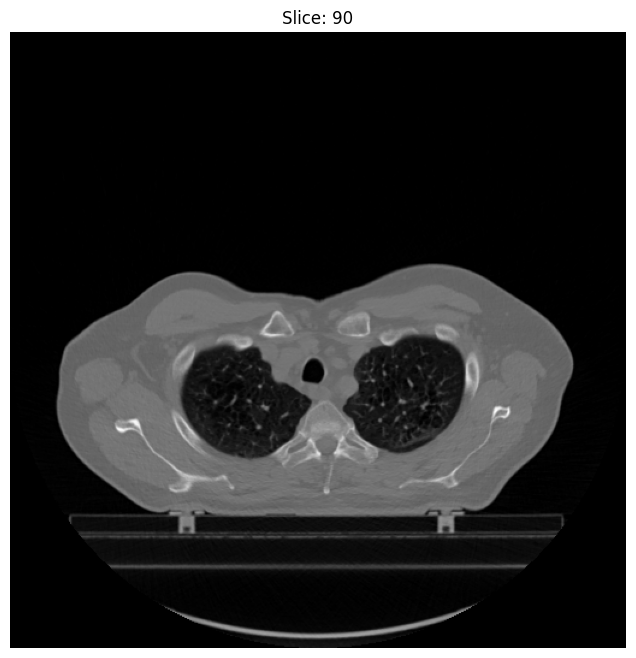

In [9]:
# Example: Interactive slice viewing for the first patient
first_key = next(iter(patient_dict))
first_value = patient_dict[first_key]

if first_value['CT']:
  first_patient_files = load_patient_dicom_files(os.path.join(data_base_dir,first_value['CT'].replace('./','')))
slices = [dcm.pixel_array for dcm in first_patient_files]


plt.figure(figsize=(8, 8))
plt.imshow(slices[90], cmap=plt.cm.gray)
plt.title(f"Slice: 90")
plt.xlabel("Pixels")
plt.ylabel("Pixels")
plt.axis('off')
plt.show()

## Statistical Analysis of the Dataset

Now, let's perform some statistical analysis on the metadata we collected.

In [10]:
# # Distribution of Patient Sex
# if 'PatientSex' in metadata_df.columns:
#     plt.figure(figsize=(6, 4))
#     sns.countplot(data=metadata_df, x='PatientSex')
#     plt.title('Distribution of Patient Sex')
#     plt.xlabel('Sex')
#     plt.ylabel('Number of Patients')
#     plt.show()

In [11]:
# # Distribution of Number of Slices per Patient
# if 'NumberOfSlices' in metadata_df.columns:
#     plt.figure(figsize=(8, 6))
#     sns.histplot(metadata_df['NumberOfSlices'], bins=30, kde=True)
#     plt.title('Distribution of Number of Slices per Patient')
#     plt.xlabel('Number of Slices')
#     plt.ylabel('Number of Patients')
#     plt.show()

# Preprocessing

In [12]:
import sys
from pathlib import Path

# Add the LCTSCProject2024 parent directory to the Python path
sys.path.append("LCTSCProject2024/")

import pandas as pd
from lctsc_preprocessor.dicom_utils import load_ct_series
from pathlib import Path
from lctsc_preprocessor.rtstruct_utils import load_rtstruct

OUTPUT_DIR = Path('./data_processed')

import numpy as np
import matplotlib.pyplot as plt
import cv2
from matplotlib.colors import ListedColormap
import scipy.ndimage as ndimage

In [13]:
from scipy.ndimage import zoom

def resize_volume(image: np.ndarray, dim: int):

    H, W, Z = image.shape

    zoom_factors = (
        dim / H,
        dim / W,
        1.0
    )

    resized = zoom(image, zoom=zoom_factors, order=1)
    return resized

In [14]:
def hu_windowing(image: np.ndarray, window_min = -1000, window_max = 400):
    '''
    Apply a Hounsfield Units (HU) windowing to an image.
    '''

    windowed_image = np.clip(image, window_min, window_max)

    return windowed_image

In [15]:
def zoom_on_lungs(mask:np.ndarray, pad = 0.2):

    y, x, z = np.where(mask > 0)

    x_min, x_max = x.min(), x.max()
    y_min, y_max = y.min(), y.max()
    z_min, z_max = z.min(), z.max()

    H, W, Z = mask.shape
    pad_y = int(H * pad)
    pad_x = int(W * pad)
    pad_z = int(Z * pad)

    x_min_pad = max(0, x_min - pad_x)
    x_max_pad = min(W - 1, x_max + pad_x)
    y_min_pad = max(0, y_min - pad_y)
    y_max_pad = min(H - 1, y_max + pad_y)
    z_min_pad = max(0, z_min - pad_z)
    z_max_pad = min(Z - 1, z_max + pad_z)

    return x_min_pad, x_max_pad, y_min_pad, y_max_pad, z_min_pad, z_max

In [16]:
def preprocess_case(case_id: str, ct_path: str, rtstruct_path: str, w_min: int, w_max: int, plot=False):
    ct_dir = Path(ct_path)
    rt_file = Path(rtstruct_path)

    if not ct_dir.exists() or not rt_file.exists():
        print(f"[!] Skipping {case_id}: CT or RTSTRUCT path missing.")
        return

    try:
        raw_image, pixel_dim = load_ct_series(ct_dir) ## ricordati di cambiare!!!

        print(f'Original image shape: {raw_image.shape}')
        # print(f'Original pixel dimensions: {pixel_dim}')

        rtstruct = load_rtstruct(rt_file, ct_dir)
        roi_names = rtstruct.get_roi_names()

        r_lung = rtstruct.get_roi_mask_by_name('Lung_R').astype(np.uint8)
        l_lung = rtstruct.get_roi_mask_by_name('Lung_L').astype(np.uint8)

        mask = np.maximum(r_lung, l_lung).astype(np.uint8)

        x1, x2, y1, y2, z1, z2 = zoom_on_lungs(mask)

        crop_img = raw_image[y1:y2+1, x1:x2+1, z1:z2+1]
        image = hu_windowing(crop_img, w_min, w_max)
        resize_img = resize_volume(image, 128)
        
        # Normalize to [0, 1] using HU windowing parameters
        normalized_img = (resize_img - w_min) / (w_max - w_min)

        mask_dict = {}
        for roi in roi_names:
            try:
                mask_roi = rtstruct.get_roi_mask_by_name(roi).astype(np.uint8)
                crop_mask = mask_roi[y1:y2+1, x1:x2+1, z1:z2+1]
                resize_mask = resize_volume(crop_mask, 128)

                mask_dict[roi] = resize_mask


            except Exception as e:
                print(f"[!] Could not extract ROI '{roi}' for {case_id}: {e}")

        print(f'Cropped image shape: {crop_img.shape}')
        print(f'Resized image shape: {resize_img.shape}')
        print(f'Normalized image range: [{normalized_img.min():.3f}, {normalized_img.max():.3f}]')
        print(f'Cropped mask shape: {crop_mask.shape}')
        print(f'Resized mask shape: {resize_mask.shape}')

        if mask_dict:
            if case_id.find('Train') != -1:
                dir = OUTPUT_DIR / 'Train'
            else:
                dir = OUTPUT_DIR / 'Test'
            dir.mkdir(parents=True, exist_ok=True)
            np.savez_compressed(
                dir / f"{case_id}.npz",
                image=normalized_img,  # Save normalized image
                pixel_dim=pixel_dim,
                **mask_dict
            )
            print(f"[✓] Saved {case_id} with {len(mask_dict)} ROIs.")

        else:
            print(f"[!] No valid ROIs found for {case_id}.")
        if plot:
            plot_roi_overlays(normalized_img, list(mask_dict.values()), list(mask_dict.keys()), [1,1,1])
    except Exception as e:
        print(f"[!] Error processing {case_id}: {e}")


def plot_roi_overlays(image, masks, roi_names, pixel_dim=[1,1,1]):
    print(pixel_dim)
    # Define colors for ROIs
    colors = plt.colormaps.get_cmap('tab10')
    alpha = 0.25  # Transparency for the overlays

    # Create a combined mask for each ROI
    combined_masks = np.zeros_like(image, dtype=np.float32)
    for i, mask in enumerate(masks):
        combined_masks += mask * (i + 1)

    # Create a custom colormap for the ROIs
    cmap = ListedColormap([colors(i) for i in range(len(roi_names)+1)])

    # Plot on all three planes
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    planes = ['Coronal', 'Axial', 'Sagittal']

    # Coronal plane
    mid_coronal = image.shape[0] // 2
    axes[0].imshow(image[mid_coronal], cmap='gray', aspect=pixel_dim[1] / pixel_dim[2])
    axes[0].imshow(combined_masks[mid_coronal], cmap=cmap, alpha=alpha, aspect=pixel_dim[1] / pixel_dim[2],vmin=0,vmax=len(roi_names)+1)
    axes[0].set_title(f"{planes[0]} Plane")
    axes[0].axis('off')

    # Axial plane
    mid_axial = image.shape[2] // 2
    axes[1].imshow(image[:, :, mid_axial], cmap='gray', aspect=pixel_dim[0] / pixel_dim[1])
    axes[1].imshow(combined_masks[:, :, mid_axial], cmap=cmap, alpha=alpha, aspect=pixel_dim[0] / pixel_dim[1],vmin=0,vmax=len(roi_names)+1)
    axes[1].set_title(f"{planes[1]} Plane")
    axes[1].axis('off')

    # Sagittal plane
    mid_sagittal = image.shape[1] // 2
    axes[2].imshow(image[:, mid_sagittal, :], cmap='gray', aspect=pixel_dim[0] / pixel_dim[2])
    axes[2].imshow(combined_masks[:, mid_sagittal, :], cmap=cmap, alpha=alpha, aspect=pixel_dim[0] / pixel_dim[2],vmin=0,vmax=len(roi_names)+1)
    axes[2].set_title(f"{planes[2]} Plane")
    axes[2].axis('off')

    # Add a legend for ROI names
    handles = [plt.Line2D([0], [0], color=colors(i+1), lw=4) for i in range(len(roi_names))]
    fig.legend(handles, roi_names, loc='upper center', ncol=len(roi_names), bbox_to_anchor=(0.5, 0.95))

    plt.tight_layout()
    plt.show()

In [16]:
for k,v in patient_dict.items():
    print(Path(data_base_dir).joinpath(v["CT"]))
    preprocess_case(
        case_id = k,
        ct_path = Path(data_base_dir).joinpath(v["CT"]),
        rtstruct_path = Path(data_base_dir).joinpath(v["RTSTRUCT"]).joinpath('1-1.dcm'),
        w_min = -1000,
        w_max = 400,
        plot=False
    )

LCTSC/LCTSC-Test-S1-101/1.3.6.1.4.1.14519.5.2.1.7014.4598.492964872630309412859177308186/1.3.6.1.4.1.14519.5.2.1.7014.4598.106943890850011666503487579262
Original image shape: (512, 512, 130)
Cropped image shape: (405, 511, 102)
Resized image shape: (128, 128, 102)
Normalized image range: [-0.000, 1.000]
Cropped mask shape: (405, 511, 102)
Resized mask shape: (128, 128, 102)
[✓] Saved LCTSC-Test-S1-101 with 5 ROIs.
LCTSC/LCTSC-Test-S1-102/1.3.6.1.4.1.14519.5.2.1.7014.4598.238478060677653494401819620444/1.3.6.1.4.1.14519.5.2.1.7014.4598.639871532605224417554459681163
Original image shape: (512, 512, 148)
Cropped image shape: (408, 474, 99)
Resized image shape: (128, 128, 99)
Normalized image range: [-0.000, 1.000]
Cropped mask shape: (408, 474, 99)
Resized mask shape: (128, 128, 99)
[✓] Saved LCTSC-Test-S1-102 with 5 ROIs.
LCTSC/LCTSC-Test-S1-103/1.3.6.1.4.1.14519.5.2.1.7014.4598.816327386653410772475068003264/1.3.6.1.4.1.14519.5.2.1.7014.4598.578895540487402949445746417374
Original ima

In [18]:
# Visualize a preprocessed case
data = np.load(OUTPUT_DIR / "Train" / "LCTSC-Train-S1-001.npz")
image = data['image']
mask_rlung = data['Lung_R']
mask_llung = data['Lung_L']


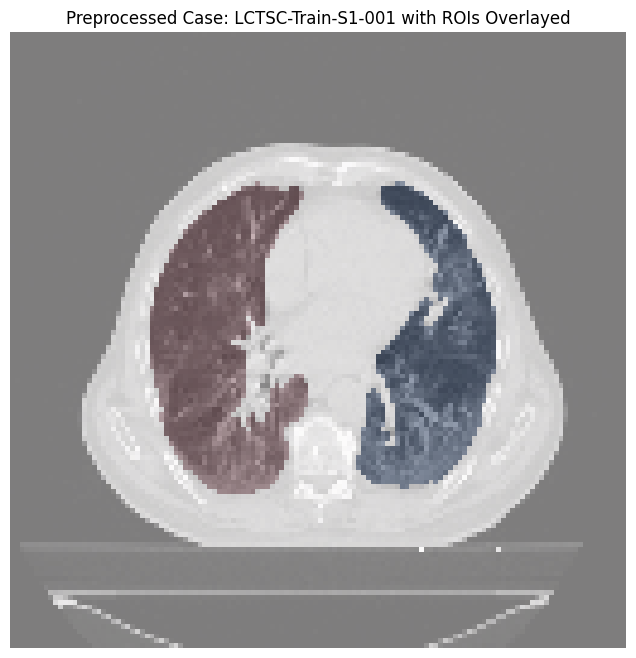

In [19]:
plt.figure(figsize=(8, 8))
plt.imshow(image[:, :, image.shape[2] // 2], cmap='gray')
plt.imshow(mask_rlung[:, :, image.shape[2] // 2], cmap='Reds', alpha=0.3)
plt.imshow(mask_llung[:, :, image.shape[2] // 2], cmap='Blues', alpha=0.3)
plt.title(f"Preprocessed Case: LCTSC-Train-S1-001 with ROIs Overlayed")
plt.axis('off')
plt.show()

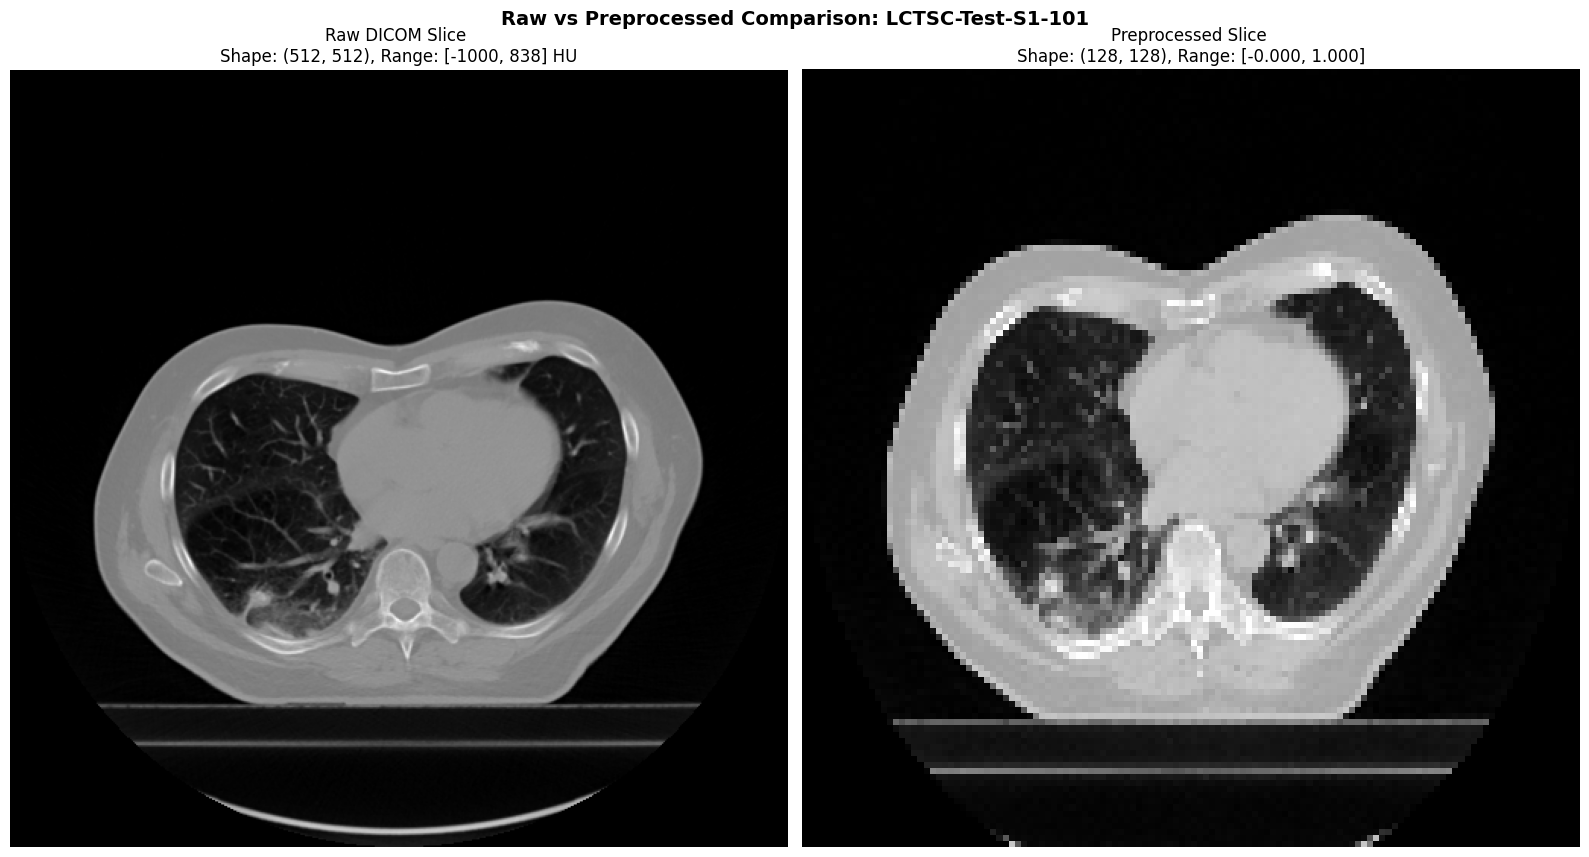

Raw image shape: (512, 512, 130)
Crop region: x=[1:511], y=[78:482], z=[0:101]
Preprocessed image shape: (128, 128, 102)

Preprocessing steps:
  1. HU windowing: [-1000, 400]
  2. Lung-based cropping (with 20% padding)
  3. Resize to 128x128 (preserving z-dimension)
  4. Normalization to [0, 1]


In [20]:
# Comparison between raw DICOM slice and preprocessed slice (same anatomical region)
# We need to apply the same preprocessing steps to find corresponding slices

from lctsc_preprocessor.dicom_utils import load_ct_series
from lctsc_preprocessor.rtstruct_utils import load_rtstruct

# Load raw CT data using the same loader as preprocessing
first_key = next(iter(patient_dict))
first_value = patient_dict[first_key]

ct_path = Path(data_base_dir).joinpath(first_value['CT'])
rt_path = Path(data_base_dir).joinpath(first_value['RTSTRUCT']).joinpath('1-1.dcm')

# Load raw image and get crop coordinates
raw_image, pixel_dim = load_ct_series(ct_path)
rtstruct = load_rtstruct(rt_path, ct_path)

r_lung = rtstruct.get_roi_mask_by_name('Lung_R').astype(np.uint8)
l_lung = rtstruct.get_roi_mask_by_name('Lung_L').astype(np.uint8)
mask = np.maximum(r_lung, l_lung).astype(np.uint8)

# Get crop coordinates (same as in preprocess_case)
x1, x2, y1, y2, z1, z2 = zoom_on_lungs(mask)

# Load preprocessed data
if 'Train' in first_key:
    preprocessed_data = np.load(OUTPUT_DIR / "Train" / f"{first_key}.npz")
else:
    preprocessed_data = np.load(OUTPUT_DIR / "Test" / f"{first_key}.npz")
preprocessed_image = preprocessed_data['image']

# Pick middle slice of the CROPPED region in raw image
raw_cropped_middle_z = (z1 + z2) // 2
raw_slice = raw_image[:, :, raw_cropped_middle_z]

# Corresponding preprocessed slice (middle of preprocessed volume)
preprocessed_middle_idx = preprocessed_image.shape[2] // 2
preprocessed_slice = preprocessed_image[:, :, preprocessed_middle_idx]

# Create comparison plot
fig, axes = plt.subplots(1, 2, figsize=(16, 9))

# Raw slice (same z-position as preprocessed middle)
axes[0].imshow(raw_slice, cmap='gray')
axes[0].set_title(f'Raw DICOM Slice \nShape: {raw_slice.shape}, Range: [{raw_slice.min():.0f}, {raw_slice.max():.0f}] HU')
axes[0].axis('off')

# Preprocessed slice
axes[1].imshow(preprocessed_slice, cmap='gray')
axes[1].set_title(f'Preprocessed Slice \nShape: {preprocessed_slice.shape}, Range: [{preprocessed_slice.min():.3f}, {preprocessed_slice.max():.3f}]')
axes[1].axis('off')

plt.suptitle(f'Raw vs Preprocessed Comparison: {first_key}', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Raw image shape: {raw_image.shape}")
print(f"Crop region: x=[{x1}:{x2}], y=[{y1}:{y2}], z=[{z1}:{z2}]")
print(f"Preprocessed image shape: {preprocessed_image.shape}")
print(f"\nPreprocessing steps:")
print(f"  1. HU windowing: [-1000, 400]")
print(f"  2. Lung-based cropping (with 20% padding)")
print(f"  3. Resize to 128x128 (preserving z-dimension)")
print(f"  4. Normalization to [0, 1]")

In [17]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import numpy as np
import albumentations as A
from albumentations.pytorch import ToTensorV2
import time # To time epochs
from tqdm import tqdm # For progress bars

In [18]:
import torch
import gc

if torch.cuda.is_available():
    torch.cuda.empty_cache()
    gc.collect()
    print(f"GPU memory cleared. Available: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.2f} GB")

GPU memory cleared. Available: 8.00 GB


In [23]:
# Data Augmentation Pipeline with Albumentations
train_transform = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.Rotate(limit=15, p=0.5, border_mode=0),
    A.GaussNoise(std_range=(0.03, 0.1), p=0.3),
    A.RandomBrightnessContrast(brightness_limit=0.1, contrast_limit=0.1, p=0.3),
    A.GaussianBlur(blur_limit=(3, 5), p=0.2),
    ToTensorV2(),
])

val_transform = A.Compose([
    ToTensorV2(),
])

class LCTSC_Dataset(Dataset):
    def __init__(self, data_dir, transform=None, validation=False):
        self.data_dir = data_dir
        self.transform = transform
        self.slices = []
        self.data_cache = {}  # In-memory cache for actual numpy arrays
        self.is_validation = validation
        
        # Load all .npz files into memory once during initialization
        print("Loading dataset into memory...")
        for file_name in sorted(os.listdir(data_dir)):
            if file_name.endswith('.npz'):
                file_path = os.path.join(data_dir, file_name)
                try:
                    # Load and extract arrays immediately (not lazy)
                    npz_file = np.load(file_path)
                    self.data_cache[file_path] = {
                        'image': npz_file['image'],
                        'Lung_R': npz_file['Lung_R'],
                        'Lung_L': npz_file['Lung_L']
                    }
                    npz_file.close()  # Close the file handle
                    
                    num_slices = self.data_cache[file_path]['image'].shape[2]
                    for slice_idx in range(num_slices):
                        self.slices.append((file_path, slice_idx))
                    print(f"  ✓ Loaded {file_name}: {num_slices} slices")
                except Exception as e:
                    print(f"  ✗ Error loading {file_name}: {e}")
        
        print(f"Total slices loaded: {len(self.slices)}\n")

    def __len__(self):
        return len(self.slices)

    def __getitem__(self, idx):
        file_path, slice_idx = self.slices[idx]
        # Access cached data (no disk I/O)
        data = self.data_cache[file_path]
        
        image = data['image'][:, :, slice_idx].astype(np.float32)
        mask_r = data['Lung_R'][:, :, slice_idx].astype(np.float32)
        mask_l = data['Lung_L'][:, :, slice_idx].astype(np.float32)
        mask = np.maximum(mask_r, mask_l).astype(np.float32)

        # Apply transforms (same transform to both image and mask)
        if self.transform:
            transformed = self.transform(image=image, mask=mask)
            image = transformed['image']
            mask = transformed['mask']
        else:
            image = torch.from_numpy(image).float()
            mask = torch.from_numpy(mask).float()
        
        # Ensure channel dimension: (1, H, W)
        if image.dim() == 2:
            image = image.unsqueeze(0)
        if mask.dim() == 2:
            mask = mask.unsqueeze(0)
        
        return image.float(), mask.float()

In [24]:
TRAIN_IMAGE_DIR = OUTPUT_DIR / 'Train'
VAL_IMAGE_DIR = OUTPUT_DIR / 'Test'

batch_size = 64

# Use augmentation for training, no augmentation for validation
train_dataset = LCTSC_Dataset(data_dir=TRAIN_IMAGE_DIR, transform=train_transform, validation=False)
val_dataset = LCTSC_Dataset(data_dir=VAL_IMAGE_DIR, transform=val_transform, validation=True)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=False, pin_memory=True, num_workers=4)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, pin_memory=True, num_workers=4)

print(f"Train dataset: {len(train_dataset)} slices (with augmentation)")
print(f"Val dataset: {len(val_dataset)} slices (no augmentation)")

if train_loader:
    print("\nChecking one batch from train_loader...")
    try:
        images, masks = next(iter(train_loader))
        print(f"Image batch shape: {images.shape}, range: [{images.min():.3f}, {images.max():.3f}]")
        print(f"Mask batch shape: {masks.shape}, range: [{masks.min():.3f}, {masks.max():.3f}]")
        print("Successfully loaded one batch from train_loader.")
    except Exception as e:
        print(f"Error loading batch from train_loader: {e}")


if val_loader:
    print("\nChecking one batch from val_loader...")
    try:
        images, masks = next(iter(val_loader))
        print(f"Image batch shape: {images.shape}, range: [{images.min():.3f}, {images.max():.3f}]")
        print(f"Mask batch shape: {masks.shape}, range: [{masks.min():.3f}, {masks.max():.3f}]")
        print("Successfully loaded one batch from val_loader.")
    except Exception as e:
        print(f"Error loading batch from val_loader: {e}")

Loading dataset into memory...
  ✓ Loaded LCTSC-Train-S1-001.npz: 109 slices
  ✓ Loaded LCTSC-Train-S1-002.npz: 118 slices
  ✓ Loaded LCTSC-Train-S1-003.npz: 124 slices
  ✓ Loaded LCTSC-Train-S1-004.npz: 115 slices
  ✓ Loaded LCTSC-Train-S1-005.npz: 100 slices
  ✓ Loaded LCTSC-Train-S1-006.npz: 99 slices
  ✓ Loaded LCTSC-Train-S1-007.npz: 102 slices
  ✓ Loaded LCTSC-Train-S1-008.npz: 98 slices
  ✓ Loaded LCTSC-Train-S1-009.npz: 122 slices
  ✓ Loaded LCTSC-Train-S1-010.npz: 87 slices
  ✓ Loaded LCTSC-Train-S1-011.npz: 112 slices
  ✓ Loaded LCTSC-Train-S1-012.npz: 102 slices
  ✓ Loaded LCTSC-Train-S2-001.npz: 132 slices
  ✓ Loaded LCTSC-Train-S2-002.npz: 124 slices
  ✓ Loaded LCTSC-Train-S2-003.npz: 118 slices
  ✓ Loaded LCTSC-Train-S2-004.npz: 135 slices
  ✓ Loaded LCTSC-Train-S2-005.npz: 110 slices
  ✓ Loaded LCTSC-Train-S2-006.npz: 107 slices
  ✓ Loaded LCTSC-Train-S2-007.npz: 121 slices
  ✓ Loaded LCTSC-Train-S2-008.npz: 127 slices
  ✓ Loaded LCTSC-Train-S2-009.npz: 126 slices
  ✓ Lo

In [25]:
import segmentation_models_pytorch as smp

# Define the three models to compare
def get_models():
    """Returns a dictionary of model configurations."""
    models = {
        'UNet': smp.Unet(
            encoder_name="resnet34",
            encoder_weights=None,
            in_channels=1,
            classes=1,
            encoder_depth=4,
            decoder_channels=(512, 256, 128, 64)
        ),
        'UNetPlusPlus': smp.UnetPlusPlus(
            encoder_name="resnet34",
            encoder_weights=None,
            in_channels=1,
            classes=1,
            encoder_depth=4,
            decoder_channels=(512, 256, 128, 64)
        ),
        'MAnet': smp.MAnet(
            encoder_name="resnet34",
            encoder_weights=None,
            in_channels=1,
            classes=1,
            encoder_depth=4,
            decoder_channels=(512, 256, 128, 64)
        )
    }
    return models

# Preview model architectures
for name, model in get_models().items():
    total_params = sum(p.numel() for p in model.parameters())
    print(f"{name}: {total_params:,} parameters")

UNet: 27,955,201 parameters
UNetPlusPlus: 28,656,385 parameters
MAnet: 30,955,169 parameters


In [26]:
from segmentation_models_pytorch.losses import DiceLoss

def get_loss_fn():
    """Returns the loss function for training."""
    return DiceLoss(
        mode='binary',
        from_logits=True,
    )

def get_optimizer_and_scheduler(model, lr=1e-4):
    """Returns optimizer and scheduler for a given model."""
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, 
        mode='min', 
        factor=0.5, 
        patience=5,
    )
    return optimizer, scheduler

In [27]:
def train_one_epoch(model, dataloader, loss_fn, optimizer, device):
    model.train()
    running_loss = 0.0
    batch_losses = []
    
    pbar = tqdm(dataloader, desc="Training", leave=True)
    for batch_idx, (images, masks) in enumerate(pbar):
        images = images.to(device)
        masks = masks.to(device)
        
        # Ensure consistent dtype before autocast
        images = images.float()
        masks = masks.float()
        
        optimizer.zero_grad()
        
        with torch.autocast(device_type="cuda"):
            outputs = model(images)
            loss = loss_fn(outputs, masks)
        
        loss.backward()
        
        # Log gradient statistics
        grad_norm = torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        
        optimizer.step()
        
        running_loss += loss.item() * images.size(0)
        batch_losses.append(loss.item())
        
        # Update progress bar with current metrics
        avg_loss = sum(batch_losses) / len(batch_losses)
        pbar.set_postfix({
            'batch_loss': f'{loss.item():.6f}',
            'avg_loss': f'{avg_loss:.6f}',
            'grad_norm': f'{grad_norm:.4f}',
            'out_range': f'[{outputs.min():.2f}, {outputs.max():.2f}]'
        })
    
    epoch_loss = running_loss / len(dataloader.dataset)
    return epoch_loss, batch_losses

In [28]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

In [29]:
# Training configuration
NUM_EPOCHS = 50
EARLY_STOPPING_PATIENCE = 10
EARLY_STOPPING_MIN_DELTA = 0.001

# Dictionary to store results for all models
training_results = {}

def train_model(model_name, model, train_loader, val_loader, device, num_epochs=NUM_EPOCHS):
    """
    Train a single model and return results dictionary.
    """
    print(f"\n{'='*80}")
    print(f"TRAINING MODEL: {model_name}")
    print(f"{'='*80}")
    
    # Move model to device
    model.to(device)
    
    # Get loss function, optimizer, scheduler
    loss_fn = get_loss_fn()
    optimizer, scheduler = get_optimizer_and_scheduler(model)
    
    # Model info
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"Total parameters: {total_params:,}")
    print(f"Trainable parameters: {trainable_params:,}")
    print(f"Training samples: {len(train_loader.dataset)} slices")
    print(f"Validation samples: {len(val_loader.dataset)} slices")
    
    # Early stopping variables
    early_stopping_counter = 0
    best_val_loss = float('inf')
    best_model_state = None
    
    # Tracking variables
    train_losses = []
    val_losses = []
    
    # Start timing
    total_start_time = time.time()
    
    for epoch in range(num_epochs):
        print(f"\nEpoch {epoch + 1}/{num_epochs}")
        epoch_start_time = time.time()
        
        # Training phase
        model.train()
        running_loss = 0.0
        
        pbar = tqdm(train_loader, desc="Training", leave=True)
        for images, masks in pbar:
            images = images.to(device).float()
            masks = masks.to(device).float()
            
            optimizer.zero_grad()
            
            with torch.autocast(device_type="cuda"):
                outputs = model(images)
                loss = loss_fn(outputs, masks)
            
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            
            running_loss += loss.item() * images.size(0)
            pbar.set_postfix({'loss': f'{loss.item():.6f}'})
        
        train_loss = running_loss / len(train_loader.dataset)
        train_losses.append(train_loss)
        
        # Validation phase
        model.eval()
        running_vloss = 0.0
        
        with torch.no_grad():
            for vimages, vmasks in tqdm(val_loader, desc="Validating", leave=True):
                vimages = vimages.to(device).float()
                vmasks = vmasks.to(device).float()
                
                with torch.autocast(device_type="cuda"):
                    voutputs = model(vimages)
                    vloss = loss_fn(voutputs, vmasks)
                
                running_vloss += vloss.item() * vimages.size(0)
        
        val_loss = running_vloss / len(val_loader.dataset)
        val_losses.append(val_loss)
        
        scheduler.step(val_loss)
        
        epoch_time = time.time() - epoch_start_time
        print(f"Train Loss: {train_loss:.6f} | Val Loss: {val_loss:.6f} | Time: {epoch_time:.2f}s | LR: {optimizer.param_groups[0]['lr']:.2e}")
        
        # Early stopping check
        if val_loss < best_val_loss - EARLY_STOPPING_MIN_DELTA:
            best_val_loss = val_loss
            best_model_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            early_stopping_counter = 0
            print(f"  ✓ New best validation loss: {best_val_loss:.6f}")
        else:
            early_stopping_counter += 1
            print(f"  ⚠ EarlyStopping counter: {early_stopping_counter}/{EARLY_STOPPING_PATIENCE}")
        
        if early_stopping_counter >= EARLY_STOPPING_PATIENCE:
            print(f"\nEarly stopping triggered at epoch {epoch + 1}!")
            break
    
    total_training_time = time.time() - total_start_time
    
    # Load best model and save
    if best_model_state is not None:
        model.load_state_dict(best_model_state)
        model.to(device)
    
    # Save the best model
    save_path = f'./{model_name.lower()}_best.pth'
    model.save_pretrained(save_path)
    print(f"\n✓ Best model saved to: {save_path}")
    
    # Compile results
    results = {
        'train_losses': train_losses,
        'val_losses': val_losses,
        'best_val_loss': best_val_loss,
        'total_training_time': total_training_time,
        'epochs_trained': len(train_losses),
        'model_path': save_path,
        'total_params': total_params
    }
    
    print(f"\n{'='*80}")
    print(f"COMPLETED: {model_name}")
    print(f"Best Val Loss: {best_val_loss:.6f}")
    print(f"Total Training Time: {total_training_time/60:.2f} minutes")
    print(f"{'='*80}")
    
    return results

# Train all three models
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Total GPU memory: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.2f} GB")

models_to_train = get_models()

for model_name, model in models_to_train.items():
    # Clear GPU memory before each model
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        gc.collect()
    
    # Train the model
    results = train_model(
        model_name=model_name,
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        device=device,
        num_epochs=NUM_EPOCHS
    )
    
    # Store results
    training_results[model_name] = results

print(f"\n{'='*80}")
print("ALL MODELS TRAINED SUCCESSFULLY!")
print(f"{'='*80}")

Using device: cuda
GPU: NVIDIA GeForce RTX 3070
Total GPU memory: 8.00 GB

TRAINING MODEL: UNet
Total parameters: 27,955,201
Trainable parameters: 27,955,201
Training samples: 4416 slices
Validation samples: 2719 slices

Epoch 1/50


Validating: 100%|██████████| 43/43 [00:02<00:00, 16.04it/s]


Train Loss: 0.525656 | Val Loss: 0.217501 | Time: 16.40s | LR: 1.00e-04
  ✓ New best validation loss: 0.217501

Epoch 2/50


Validating: 100%|██████████| 43/43 [00:02<00:00, 16.72it/s]


Train Loss: 0.271608 | Val Loss: 0.106340 | Time: 14.17s | LR: 1.00e-04
  ✓ New best validation loss: 0.106340

Epoch 3/50


...

Train Loss: nan | Val Loss: nan | Time: 13.05s | LR: 5.00e-05
  ⚠ EarlyStopping counter: 8/10

Epoch 19/50


Validating: 100%|██████████| 43/43 [00:02<00:00, 17.34it/s]


Train Loss: nan | Val Loss: nan | Time: 13.51s | LR: 5.00e-05
  ⚠ EarlyStopping counter: 9/10

Epoch 20/50


Validating: 100%|██████████| 43/43 [00:02<00:00, 18.35it/s]


Train Loss: nan | Val Loss: nan | Time: 13.03s | LR: 5.00e-05
  ⚠ EarlyStopping counter: 10/10

Early stopping triggered at epoch 20!

✓ Best model saved to: ./manet_best.pth

COMPLETED: MAnet
Best Val Loss: 0.048874
Total Training Time: 4.43 minutes

ALL MODELS TRAINED SUCCESSFULLY!


In [27]:
# Display training results summary
print("="*80)
print("TRAINING RESULTS SUMMARY")
print("="*80)

for model_name, results in training_results.items():
    print(f"\n{model_name}:")
    print(f"  - Best Validation Loss: {results['best_val_loss']:.6f}")
    print(f"  - Epochs Trained: {results['epochs_trained']}")
    print(f"  - Total Training Time: {results['total_training_time']/60:.2f} minutes")
    print(f"  - Model Parameters: {results['total_params']:,}")
    print(f"  - Saved to: {results['model_path']}")

# Find best model
best_model_name = min(training_results, key=lambda x: training_results[x]['best_val_loss'])
print(f"\n{'='*80}")
print(f"🏆 BEST MODEL: {best_model_name} (Val Loss: {training_results[best_model_name]['best_val_loss']:.6f})")
print(f"{'='*80}")

TRAINING RESULTS SUMMARY

UNet:
  - Best Validation Loss: 0.053843
  - Epochs Trained: 24
  - Total Training Time: 5.96 minutes
  - Model Parameters: 27,955,201
  - Saved to: ./unet_best.pth

UNetPlusPlus:
  - Best Validation Loss: 0.045275
  - Epochs Trained: 36
  - Total Training Time: 11.32 minutes
  - Model Parameters: 28,656,385
  - Saved to: ./unetplusplus_best.pth

MAnet:
  - Best Validation Loss: 0.043963
  - Epochs Trained: 45
  - Total Training Time: 10.75 minutes
  - Model Parameters: 30,955,169
  - Saved to: ./manet_best.pth

🏆 BEST MODEL: MAnet (Val Loss: 0.043963)


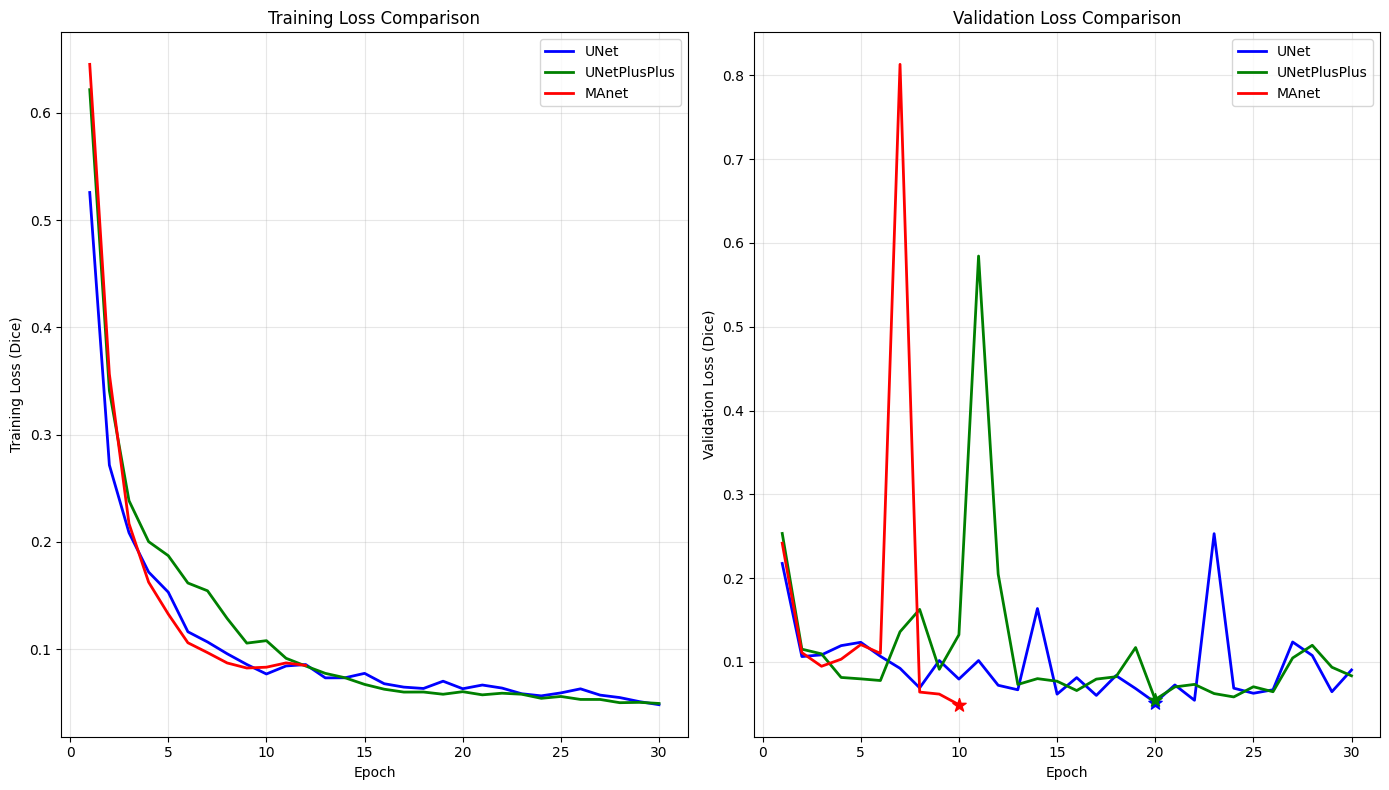

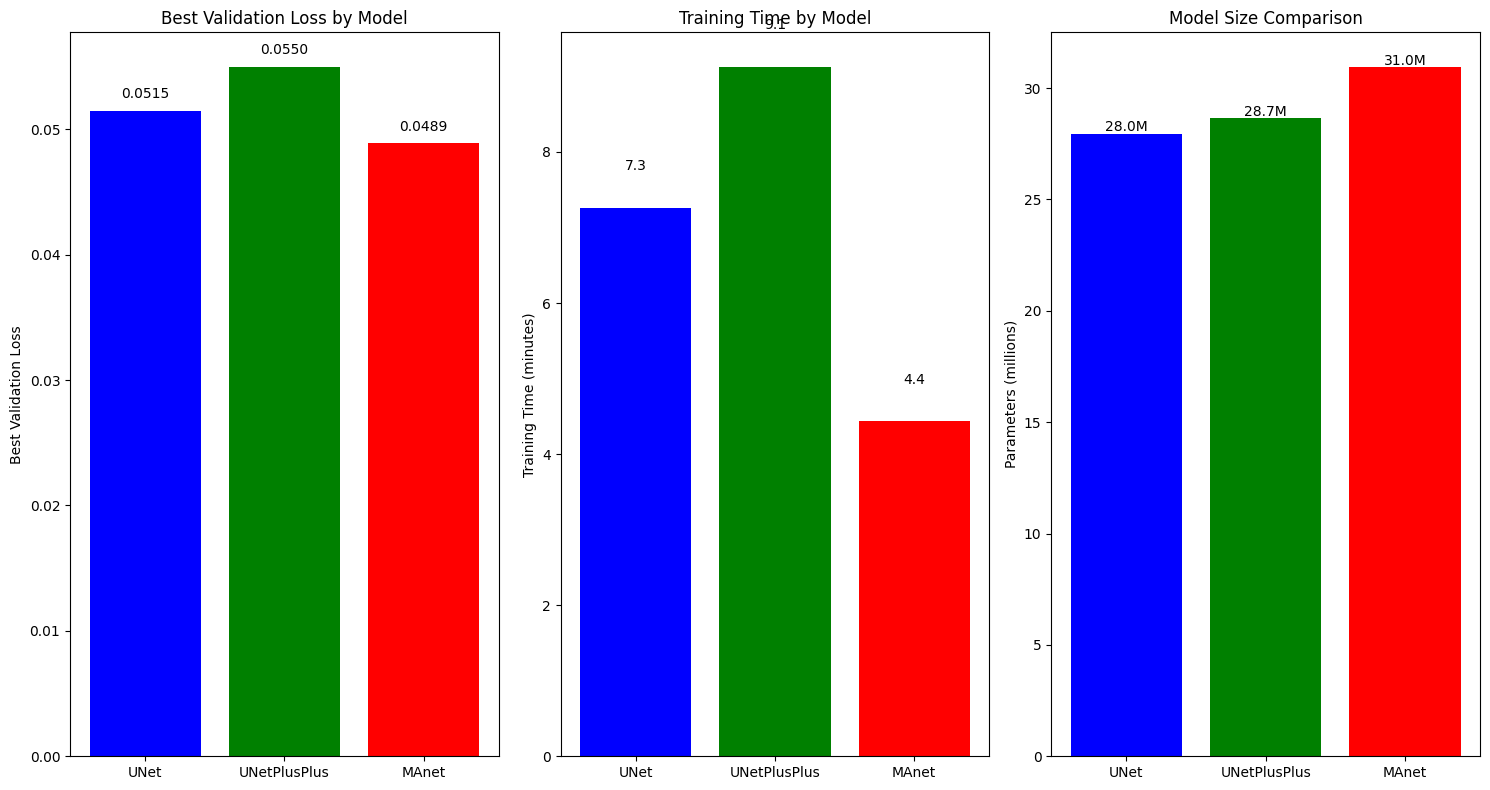


✓ Comparison plots saved to: training_comparison.png, model_comparison_2d.png


In [30]:
# Plot training curves comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 8))

colors = {'UNet': 'blue', 'UNetPlusPlus': 'green', 'MAnet': 'red'}

# Training Loss
ax1 = axes[0]
for model_name, results in training_results.items():
    epochs = range(1, len(results['train_losses']) + 1)
    ax1.plot(epochs, results['train_losses'], label=model_name, color=colors.get(model_name, 'gray'), linewidth=2)
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Training Loss (Dice)')
ax1.set_title('Training Loss Comparison')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Validation Loss
ax2 = axes[1]
for model_name, results in training_results.items():
    epochs = range(1, len(results['val_losses']) + 1)
    ax2.plot(epochs, results['val_losses'], label=model_name, color=colors.get(model_name, 'gray'), linewidth=2)
    # Mark best validation loss
    best_epoch = results['val_losses'].index(min(results['val_losses'])) + 1
    ax2.scatter([best_epoch], [results['best_val_loss']], color=colors.get(model_name, 'gray'), s=100, zorder=5, marker='*')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Validation Loss (Dice)')
ax2.set_title('Validation Loss Comparison')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_comparison_2d.png', dpi=150, bbox_inches='tight')
plt.show()

# Bar chart comparison
fig, axes = plt.subplots(1, 3, figsize=(15, 8))

model_names = list(training_results.keys())
best_losses = [training_results[m]['best_val_loss'] for m in model_names]
training_times = [training_results[m]['total_training_time'] / 60 for m in model_names]
params = [training_results[m]['total_params'] / 1e6 for m in model_names]

# Best Validation Loss
axes[0].bar(model_names, best_losses, color=[colors[m] for m in model_names])
axes[0].set_ylabel('Best Validation Loss')
axes[0].set_title('Best Validation Loss by Model')
for i, v in enumerate(best_losses):
    axes[0].text(i, v + 0.001, f'{v:.4f}', ha='center', fontsize=10)

# Training Time
axes[1].bar(model_names, training_times, color=[colors[m] for m in model_names])
axes[1].set_ylabel('Training Time (minutes)')
axes[1].set_title('Training Time by Model')
for i, v in enumerate(training_times):
    axes[1].text(i, v + 0.5, f'{v:.1f}', ha='center', fontsize=10)

# Model Parameters
axes[2].bar(model_names, params, color=[colors[m] for m in model_names])
axes[2].set_ylabel('Parameters (millions)')
axes[2].set_title('Model Size Comparison')
for i, v in enumerate(params):
    axes[2].text(i, v + 0.1, f'{v:.1f}M', ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('model_comparison_2d.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✓ Comparison plots saved to: training_comparison.png, model_comparison_2d.png")

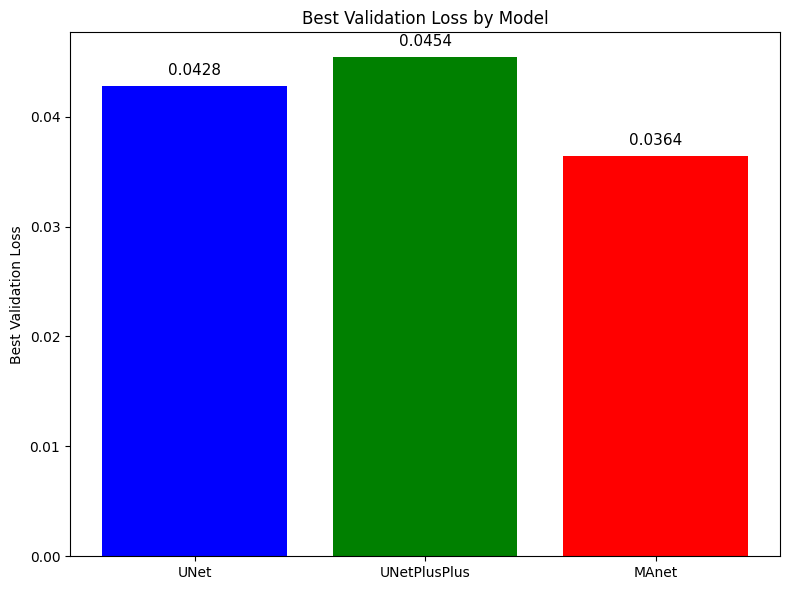

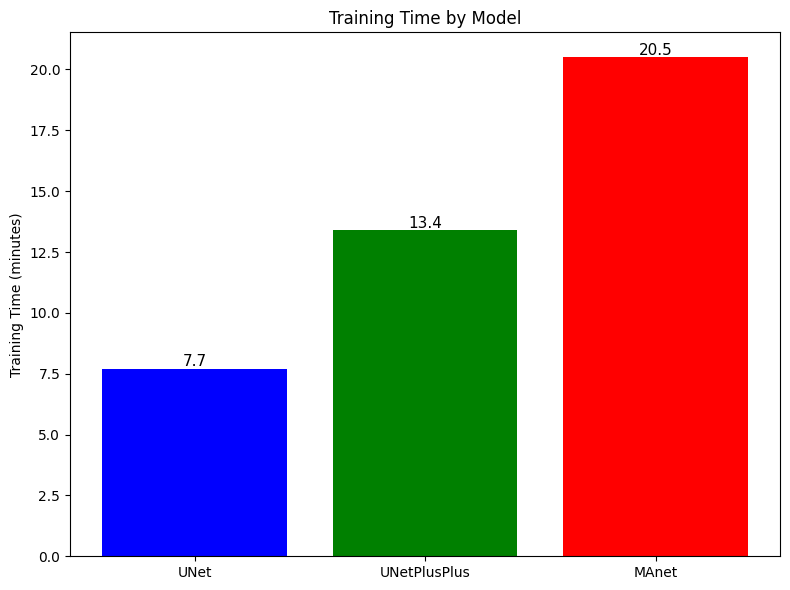

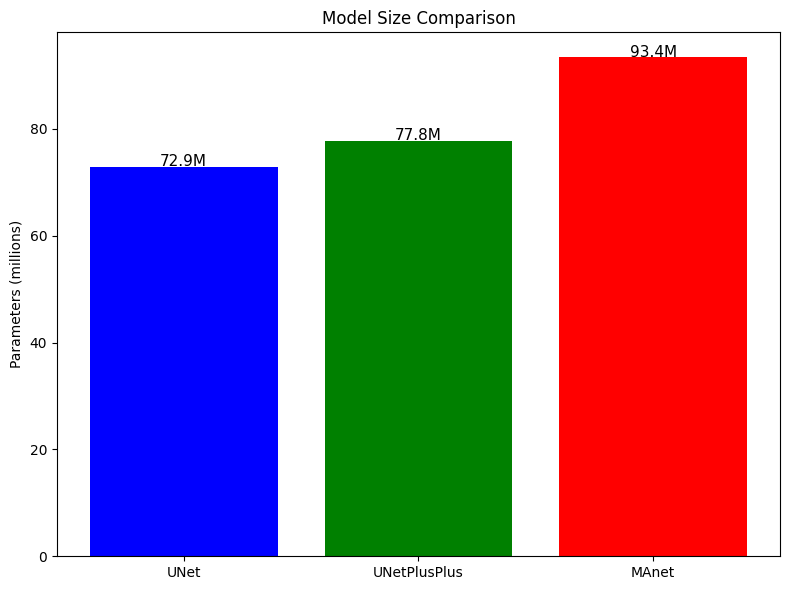

✓ Plots saved: val_loss_comparison_3d.png, training_time_comparison_3d.png, params_comparison_3d.png


In [31]:
# Model comparison - separate plots

model_names = ["UNet", "UNetPlusPlus", "MAnet"]
best_losses = [0.0428, 0.0454, 0.0364]
training_times = [7.7, 13.4, 20.5]
params = [72.9, 77.8, 93.4]
colors = ["blue", "green", "red"]

# Plot 1: Best Validation Loss
plt.figure(figsize=(8, 6))
bars = plt.bar(model_names, best_losses, color=colors)
plt.ylabel('Best Validation Loss')
plt.title('Best Validation Loss by Model')
for i, v in enumerate(best_losses):
    plt.text(i, v + 0.001, f'{v:.4f}', ha='center', fontsize=11)
plt.tight_layout()
plt.savefig('val_loss_comparison_3d.png', dpi=150, bbox_inches='tight')
plt.show()

# Plot 2: Training Time
plt.figure(figsize=(8, 6))
bars = plt.bar(model_names, training_times, color=colors)
plt.ylabel('Training Time (minutes)')
plt.title('Training Time by Model')
for i, v in enumerate(training_times):
    plt.text(i, v + 0.1, f'{v:.1f}', ha='center', fontsize=11)
plt.tight_layout()
plt.savefig('training_time_comparison_3d.png', dpi=150, bbox_inches='tight')
plt.show()

# Plot 3: Model Parameters
plt.figure(figsize=(8, 6))
bars = plt.bar(model_names, params, color=colors)
plt.ylabel('Parameters (millions)')
plt.title('Model Size Comparison')
for i, v in enumerate(params):
    plt.text(i, v + 0.1, f'{v:.1f}M', ha='center', fontsize=11)
plt.tight_layout()
plt.savefig('params_comparison_3d.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Plots saved: val_loss_comparison_3d.png, training_time_comparison_3d.png, params_comparison_3d.png")

In [31]:
# Load the best performing model for inference
best_model_name = min(training_results, key=lambda x: training_results[x]['best_val_loss'])
best_model_path = training_results[best_model_name]['model_path']

print(f"Loading best model: {best_model_name} from {best_model_path}")
model = smp.from_pretrained(best_model_path)
model.to(device)
print(f"✓ Model loaded successfully")

Loading best model: MAnet from ./manet_best.pth
Loading weights from local directory
✓ Model loaded successfully


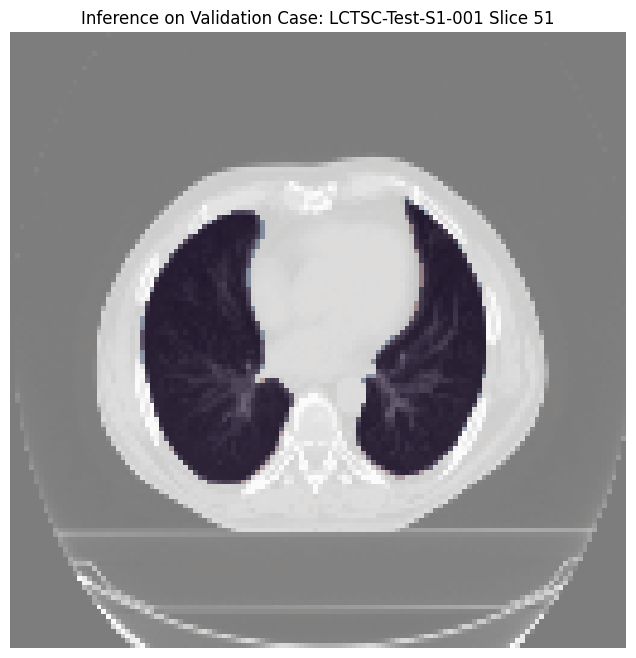

In [32]:
# Make inference on a validation case
val_case_path = OUTPUT_DIR / 'Test' / 'LCTSC-Test-S2-201.npz'
data = np.load(val_case_path)
image = data['image']
mask_rlung = data['Lung_R']
mask_llung = data['Lung_L']
ground_truth_mask = np.maximum(mask_rlung, mask_llung).astype(np.float32)

# Preprocess image slices
slice_idx = image.shape[2] // 2
input_image = image[:, :, slice_idx]
input_image_tensor = torch.from_numpy(input_image).unsqueeze(0).unsqueeze(0).float().to(device)

model.eval()
with torch.no_grad():
    output = model(input_image_tensor)
    output_sigmoid = torch.sigmoid(output)
    output_mask = (output_sigmoid > 0.5).float().cpu().squeeze().numpy()

# Plot results
plt.figure(figsize=(8, 8))
plt.imshow(input_image, cmap='gray')
plt.imshow(output_mask, cmap='Reds', alpha=0.3)
plt.imshow(ground_truth_mask[:, :, slice_idx], cmap='Blues', alpha=0.3)
plt.title(f"Inference on Validation Case: LCTSC-Test-S1-001 Slice {slice_idx}")
plt.axis('off')
plt.show()

In [32]:
# Evaluation metrics for segmentation models
from scipy.spatial.distance import directed_hausdorff
from scipy import ndimage as ndi

def compute_metrics(pred: np.ndarray, target: np.ndarray, smooth: float = 1e-6):
    """
    Compute segmentation metrics between prediction and ground truth.
    Both inputs should be binary masks (0 or 1).
    """
    pred = pred.astype(bool).flatten()
    target = target.astype(bool).flatten()
    
    # Basic counts
    tp = np.sum(pred & target)
    fp = np.sum(pred & ~target)
    fn = np.sum(~pred & target)
    tn = np.sum(~pred & ~target)
    
    # Dice Score
    dice = (2 * tp + smooth) / (2 * tp + fp + fn + smooth)
    
    # IoU (Jaccard)
    iou = (tp + smooth) / (tp + fp + fn + smooth)
    
    # Sensitivity (Recall) - how much of the ground truth is captured
    sensitivity = (tp + smooth) / (tp + fn + smooth)
    
    # Specificity
    specificity = (tn + smooth) / (tn + fp + smooth)
    
    # Precision
    precision = (tp + smooth) / (tp + fp + smooth)
    
    # F1 Score (same as Dice for binary)
    f1 = (2 * precision * sensitivity) / (precision + sensitivity + smooth)
    
    return {
        'dice': dice,
        'iou': iou,
        'sensitivity': sensitivity,
        'specificity': specificity,
        'precision': precision,
        'f1': f1
    }

def compute_hausdorff_distance(pred: np.ndarray, target: np.ndarray):
    """
    Compute Hausdorff distance between prediction and ground truth boundaries.
    Returns HD and HD95.
    """
    # Convert to boolean for boundary detection
    pred_bool = pred.astype(bool)
    target_bool = target.astype(bool)
    
    # Get boundary points
    pred_boundary = pred_bool ^ ndi.binary_erosion(pred_bool)
    target_boundary = target_bool ^ ndi.binary_erosion(target_bool)
    
    pred_points = np.argwhere(pred_boundary)
    target_points = np.argwhere(target_boundary)
    
    if len(pred_points) == 0 or len(target_points) == 0:
        return {'hausdorff': np.nan, 'hausdorff_95': np.nan}
    
    # Compute directed Hausdorff distances
    hd_pred_to_target = directed_hausdorff(pred_points, target_points)[0]
    hd_target_to_pred = directed_hausdorff(target_points, pred_points)[0]
    
    # Hausdorff distance (max of both directions)
    hd = max(hd_pred_to_target, hd_target_to_pred)
    
    # 95th percentile Hausdorff (more robust)
    from scipy.spatial.distance import cdist
    distances = cdist(pred_points, target_points)
    min_dist_pred = distances.min(axis=1)
    min_dist_target = distances.min(axis=0)
    all_distances = np.concatenate([min_dist_pred, min_dist_target])
    hd_95 = np.percentile(all_distances, 95)
    
    return {'hausdorff': hd, 'hausdorff_95': hd_95}

In [34]:
def evaluate_model_on_validation(model, val_loader, device):
    """
    Evaluate a model on the validation set and return comprehensive metrics.
    """
    model.eval()
    all_metrics = []
    
    with torch.no_grad():
        for images, masks in tqdm(val_loader, desc="Evaluating"):
            images = images.to(device).float()
            masks = masks.cpu().numpy()
            
            with torch.autocast(device_type="cuda"):
                outputs = model(images)
            
            # Apply sigmoid and threshold
            preds = torch.sigmoid(outputs).cpu().numpy()
            preds_binary = (preds > 0.5).astype(np.float32)
            
            # Compute metrics for each sample in batch
            for i in range(images.size(0)):
                pred = preds_binary[i, 0]  # Remove channel dim
                target = masks[i, 0]
                
                # Skip empty masks (slices without lungs)
                if target.sum() == 0 and pred.sum() == 0:
                    continue
                
                metrics = compute_metrics(pred, target)
                
                # Add Hausdorff only for non-empty predictions
                if pred.sum() > 0 and target.sum() > 0:
                    hd_metrics = compute_hausdorff_distance(pred, target)
                    metrics.update(hd_metrics)
                else:
                    metrics['hausdorff'] = np.nan
                    metrics['hausdorff_95'] = np.nan
                
                all_metrics.append(metrics)
    
    # Aggregate metrics
    metrics_df = pd.DataFrame(all_metrics)
    
    summary = {
        'dice_mean': metrics_df['dice'].mean(),
        'dice_std': metrics_df['dice'].std(),
        'iou_mean': metrics_df['iou'].mean(),
        'iou_std': metrics_df['iou'].std(),
        'sensitivity_mean': metrics_df['sensitivity'].mean(),
        'precision_mean': metrics_df['precision'].mean(),
        'hausdorff_95_mean': metrics_df['hausdorff_95'].dropna().mean(),
        'hausdorff_95_std': metrics_df['hausdorff_95'].dropna().std(),
    }
    
    return summary, metrics_df

In [35]:
# Evaluate all trained models and compare
evaluation_results = {}

for model_name in training_results.keys():
    print(f"\nEvaluating {model_name}...")
    
    # Load the saved model
    model_path = training_results[model_name]['model_path']
    model = smp.from_pretrained(model_path)
    model.to(device)
    
    # Evaluate
    summary, detailed_metrics = evaluate_model_on_validation(model, val_loader, device)
    evaluation_results[model_name] = {
        'summary': summary,
        'detailed': detailed_metrics
    }
    
    print(f"  Dice: {summary['dice_mean']:.4f} ± {summary['dice_std']:.4f}")
    print(f"  IoU: {summary['iou_mean']:.4f} ± {summary['iou_std']:.4f}")
    print(f"  Sensitivity: {summary['sensitivity_mean']:.4f}")
    print(f"  Precision: {summary['precision_mean']:.4f}")
    print(f"  HD95: {summary['hausdorff_95_mean']:.2f} ± {summary['hausdorff_95_std']:.2f} pixels")

# Create comparison table
comparison_df = pd.DataFrame({
    model_name: {
        'Dice': f"{res['summary']['dice_mean']:.4f} ± {res['summary']['dice_std']:.4f}",
        'IoU': f"{res['summary']['iou_mean']:.4f} ± {res['summary']['iou_std']:.4f}",
        'Sensitivity': f"{res['summary']['sensitivity_mean']:.4f}",
        'Precision': f"{res['summary']['precision_mean']:.4f}",
        'HD95 (px)': f"{res['summary']['hausdorff_95_mean']:.2f} ± {res['summary']['hausdorff_95_std']:.2f}"
    }
    for model_name, res in evaluation_results.items()
}).T

print("\n" + "="*80)
print("MODEL COMPARISON - VALIDATION METRICS")
print("="*80)
print(comparison_df.to_string())


Evaluating UNet...
Loading weights from local directory


Evaluating: 100%|██████████| 43/43 [00:04<00:00,  8.99it/s]


  Dice: 0.9107 ± 0.1748
  IoU: 0.8660 ± 0.1894
  Sensitivity: 0.9098
  Precision: 0.9471
  HD95: 3.12 ± 6.48 pixels

Evaluating UNetPlusPlus...
Loading weights from local directory


Evaluating: 100%|██████████| 43/43 [00:05<00:00,  8.36it/s]


  Dice: 0.9066 ± 0.1723
  IoU: 0.8582 ± 0.1883
  Sensitivity: 0.8832
  Precision: 0.9644
  HD95: 3.54 ± 6.98 pixels

Evaluating MAnet...
Loading weights from local directory


Evaluating: 100%|██████████| 43/43 [00:04<00:00, 10.03it/s]

  Dice: 0.9134 ± 0.1725
  IoU: 0.8694 ± 0.1848
  Sensitivity: 0.9170
  Precision: 0.9425
  HD95: 3.06 ± 6.35 pixels

MODEL COMPARISON - VALIDATION METRICS
                         Dice              IoU Sensitivity Precision    HD95 (px)
UNet          0.9107 ± 0.1748  0.8660 ± 0.1894      0.9098    0.9471  3.12 ± 6.48
UNetPlusPlus  0.9066 ± 0.1723  0.8582 ± 0.1883      0.8832    0.9644  3.54 ± 6.98
MAnet         0.9134 ± 0.1725  0.8694 ± 0.1848      0.9170    0.9425  3.06 ± 6.35


In [36]:
# Make inference on a hidden test case
image_raw = np.load('hidden_test_set/LUNG1-001/ct.npy')

# Apply simple preprocessing: windowing, resizing, and normalization (no cropping)
w_min, w_max = -1000, 400
windowed_image = hu_windowing(image_raw, w_min, w_max)
resized_image = resize_volume(windowed_image, 128)
# Fixed normalization using windowing parameters
hidden_test_image = (resized_image - w_min) / (w_max - w_min)

print(f"Original image shape: {image_raw.shape}")
print(f"Preprocessed image shape: {hidden_test_image.shape}")
print(f"Image range: [{hidden_test_image.min():.3f}, {hidden_test_image.max():.3f}]")

Original image shape: (512, 512, 134)
Preprocessed image shape: (128, 128, 134)
Image range: [-0.000, 1.000]


In [37]:
def get_body_mask(image: np.ndarray, threshold: float = 0.6):
    """
    Create a body mask to exclude air outside the patient.
    Works on normalized [0,1] images where external air ~ 0.
    """
    from scipy import ndimage as ndi
    
    # Threshold to separate body from air
    binary = (image > threshold).astype(np.uint8)
    
    # Fill holes and get largest connected component (the body)
    filled = ndi.binary_fill_holes(binary)
    labeled, num_features = ndi.label(filled)
    
    if num_features > 0:
        # Keep only the largest component
        component_sizes = ndi.sum(filled, labeled, range(1, num_features + 1))
        largest_component = np.argmax(component_sizes) + 1
        body_mask = (labeled == largest_component).astype(np.float32)
    else:
        body_mask = filled.astype(np.float32)
    
    return body_mask

In [38]:
def interactive_slice_viewer_hidden_test(dicom_image, model, device):
    """Interactive viewer for browsing through CT scan slices of hidden test case."""
    slices = [dicom_image[:, :, i] for i in range(dicom_image.shape[2])]
    
    def show_slice(slice_num):
        input_image = slices[slice_num]
        input_image_tensor = torch.from_numpy(input_image).unsqueeze(0).unsqueeze(0).float().to(device)

        model.eval()
        with torch.no_grad():
            output = model(input_image_tensor)
            output_sigmoid = torch.sigmoid(output)
            output_mask = (output_sigmoid > 0.5).float().cpu().squeeze().numpy()

        body_mask = get_body_mask(input_image)
        filtered_mask = output_mask * body_mask

        plt.figure(figsize=(8, 8))
        plt.imshow(input_image, cmap='gray')
        plt.imshow(filtered_mask, cmap='Reds', alpha=0.3)
        plt.title(f"Slice: {slice_num}")
        plt.axis('off')
        plt.show()

    interact(show_slice, slice_num=IntSlider(min=0, max=len(slices) - 1, step=1, description='Slice Number'))

# Example: Interactive slice viewing for the hidden test case
interactive_slice_viewer_hidden_test(hidden_test_image, model, device)

interactive(children=(IntSlider(value=0, description='Slice Number', max=133), Output()), _dom_classes=('widge…

In [39]:
import plotly.graph_objects as go
from skimage import measure

slices = [hidden_test_image[:, :, i] for i in range(hidden_test_image.shape[2])]

with torch.no_grad():
    output_masks = []
    for i in range(hidden_test_image.shape[2]):
        input_image = hidden_test_image[:, :, i]
        input_image_tensor = torch.from_numpy(input_image).unsqueeze(0).unsqueeze(0).float().to(device)

        model.eval()
        output = model(input_image_tensor)
        output_sigmoid = torch.sigmoid(output)
        output_mask = (output_sigmoid > 0.5).float().cpu().squeeze().numpy()
        output_masks.append(output_mask)

# Stack output masks into a 3D volume
predicted_mask_volume = np.stack(output_masks, axis=2)

# Apply body mask to each slice and also build 3D body mask
body_mask_3d = np.zeros_like(predicted_mask_volume)
filtered_mask = np.zeros_like(predicted_mask_volume)
for i in range(hidden_test_image.shape[2]):
    body_mask = get_body_mask(hidden_test_image[:, :, i])
    body_mask_3d[:, :, i] = body_mask
    filtered_mask[:, :, i] = predicted_mask_volume[:, :, i] * body_mask

# Create 3D surfaces
fig = go.Figure()

# Body surface (gray) - now using body_mask_3d from hidden_test_image
if body_mask_3d.max() > 0:
    try:
        verts_body, faces_body, _, _ = measure.marching_cubes(body_mask_3d, level=0.5)
        fig.add_trace(go.Mesh3d(
            x=verts_body[:, 0], y=verts_body[:, 1], z=verts_body[:, 2],
            i=faces_body[:, 0], j=faces_body[:, 1], k=faces_body[:, 2],
            opacity=0.2,
            color='gray',
            name='Body Surface'
        ))
    except ValueError:
        print("Could not generate body surface")

# Predicted lung surface (red)
if filtered_mask.max() > 0:
    try:
        verts_pred, faces_pred, _, _ = measure.marching_cubes(filtered_mask, level=0.5)
        fig.add_trace(go.Mesh3d(
            x=verts_pred[:, 0], y=verts_pred[:, 1], z=verts_pred[:, 2],
            i=faces_pred[:, 0], j=faces_pred[:, 1], k=faces_pred[:, 2],
            opacity=0.6,
            color='red',
            name='Model Prediction'
        ))
    except ValueError:
        print("Could not generate prediction surface")

fig.update_layout(
    title='3D Lung Segmentation - Model Prediction',
    scene=dict(aspectmode='data'),
    width=900, height=800,
    legend=dict(x=0.02, y=0.98)
)
fig.show()

Test volume shape: (128, 128, 103)
Device: cuda
Warmup runs: 3, Timed runs: 10
Loading weights from local directory
Loading weights from local directory
Loading weights from local directory

Benchmarking UNet...
  2D (slice-by-slice): 670.5 ± 114.2 ms


Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at /pytorch/torch/csrc/autograd/python_variable_indexing.cpp:345.)
Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at /pytorch/torch/csrc/autograd/python_variable_indexing.cpp:345.)


  3D (sliding window): 291.6 ± 66.5 ms

Benchmarking UNetPlusPlus...
  2D (slice-by-slice): 644.0 ± 18.4 ms
  3D (sliding window): 581.1 ± 6.2 ms

Benchmarking MAnet...
  2D (slice-by-slice): 870.6 ± 100.1 ms
  3D (sliding window): 233.7 ± 3.9 ms

INFERENCE TIME COMPARISON (full volume)
       Model  2D Time (ms) 3D Time (ms) Speedup (2D/3D)
        UNet 670.5 ± 114.2 291.6 ± 66.5           2.30x
UNetPlusPlus  644.0 ± 18.4  581.1 ± 6.2           1.11x
       MAnet 870.6 ± 100.1  233.7 ± 3.9           3.73x


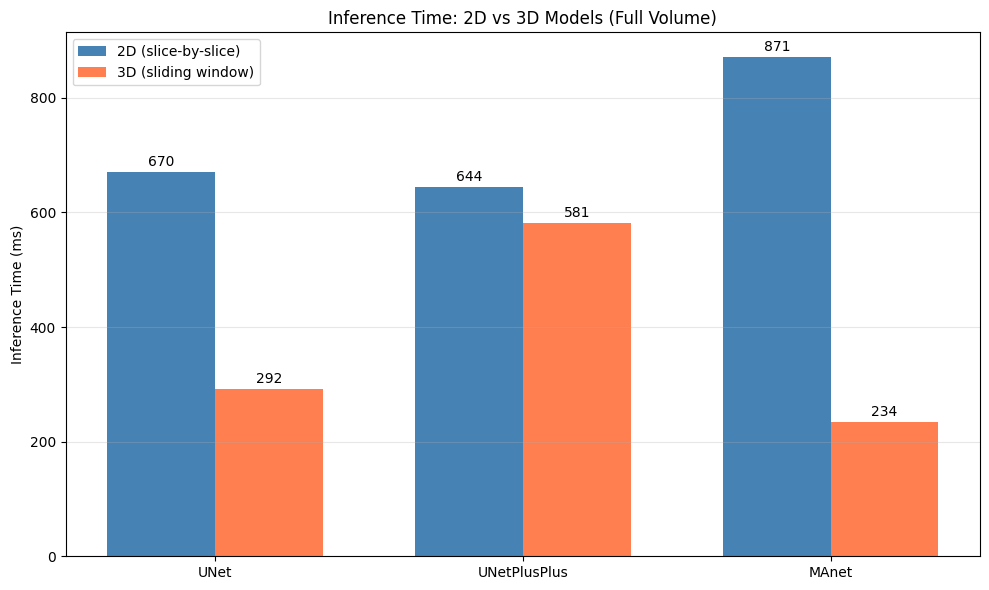

Plot saved to: inference_time_2d_vs_3d.png


In [20]:
# ============================================================================
# Inference Time Comparison: 2D (slice-by-slice) vs 3D (sliding window)
# ============================================================================
import segmentation_models_pytorch as smp_2d
import segmentation_models_pytorch_3d as smp_3d
from monai.inferers import sliding_window_inference
import time

device = 'cuda' if torch.cuda.is_available() else 'cpu'

# --- Load a test volume ---
test_vol_path = OUTPUT_DIR / 'Test' / 'LCTSC-Test-S2-201.npz'
test_data = np.load(test_vol_path)
test_image = test_data['image'].astype(np.float32)  # (128, 128, Z)
print(f"Test volume shape: {test_image.shape}")

# --- Define model loaders ---
model_names = ['UNet', 'UNetPlusPlus', 'MAnet']

def load_2d_models():
    return {
        'UNet': smp_2d.from_pretrained('./unet_best.pth'),
        'UNetPlusPlus': smp_2d.from_pretrained('./unetplusplus_best.pth'),
        'MAnet': smp_2d.from_pretrained('./manet_best.pth'),
    }

def load_3d_models():
    models_3d = {
        'UNet': smp_3d.Unet(encoder_name="resnet34", encoder_weights=None, in_channels=1, classes=1),
        'UNetPlusPlus': smp_3d.UnetPlusPlus(encoder_name="resnet34", encoder_weights=None, in_channels=1, classes=1),
        'MAnet': smp_3d.MAnet(encoder_name="resnet34", encoder_weights=None, in_channels=1, classes=1),
    }
    weights_map = {
        'UNet': './unet_3d__best.pth',
        'UNetPlusPlus': './unetplusplus_3d__best.pth',
        'MAnet': './manet_3d__best.pth',
    }
    for name, m in models_3d.items():
        m.load_state_dict(torch.load(weights_map[name], weights_only=True, map_location=device))
    return models_3d

# --- Benchmark functions ---
NUM_WARMUP = 3
NUM_RUNS = 10

@torch.no_grad()
def benchmark_2d(model, image_vol, device):
    """Infer full volume slice-by-slice (2D model)."""
    model.eval()
    model.to(device)
    H, W, Z = image_vol.shape

    # Warmup
    for _ in range(NUM_WARMUP):
        dummy = torch.randn(1, 1, H, W, device=device)
        _ = model(dummy)
    if device == 'cuda':
        torch.cuda.synchronize()

    times = []
    for _ in range(NUM_RUNS):
        if device == 'cuda':
            torch.cuda.synchronize()
        t0 = time.perf_counter()

        for z in range(Z):
            slice_tensor = torch.from_numpy(image_vol[:, :, z]).unsqueeze(0).unsqueeze(0).float().to(device)
            _ = model(slice_tensor)

        if device == 'cuda':
            torch.cuda.synchronize()
        times.append(time.perf_counter() - t0)

    return np.mean(times), np.std(times)

@torch.no_grad()
def benchmark_3d(model, image_vol, device, roi_size=(64, 64, 32)):
    """Infer full volume using sliding window (3D model)."""
    model.eval()
    model.to(device)
    input_tensor = torch.from_numpy(image_vol).unsqueeze(0).unsqueeze(0).float().to(device)

    # Warmup
    for _ in range(NUM_WARMUP):
        _ = sliding_window_inference(input_tensor, roi_size, sw_batch_size=4, predictor=model, overlap=0.5)
    if device == 'cuda':
        torch.cuda.synchronize()

    times = []
    for _ in range(NUM_RUNS):
        if device == 'cuda':
            torch.cuda.synchronize()
        t0 = time.perf_counter()

        _ = sliding_window_inference(input_tensor, roi_size, sw_batch_size=4, predictor=model, overlap=0.5, mode='gaussian')

        if device == 'cuda':
            torch.cuda.synchronize()
        times.append(time.perf_counter() - t0)

    return np.mean(times), np.std(times)

# --- Run benchmarks ---
print(f"Device: {device}")
print(f"Warmup runs: {NUM_WARMUP}, Timed runs: {NUM_RUNS}")
print(f"{'='*70}")

models_2d = load_2d_models()
models_3d = load_3d_models()

results = []
for name in model_names:
    print(f"\nBenchmarking {name}...")

    # 2D
    mean_2d, std_2d = benchmark_2d(models_2d[name], test_image, device)
    print(f"  2D (slice-by-slice): {mean_2d*1000:.1f} ± {std_2d*1000:.1f} ms")

    # Clear GPU between models
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    # 3D
    mean_3d, std_3d = benchmark_3d(models_3d[name], test_image, device)
    print(f"  3D (sliding window): {mean_3d*1000:.1f} ± {std_3d*1000:.1f} ms")

    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    results.append({
        'Model': name,
        '2D Time (ms)': f"{mean_2d*1000:.1f} ± {std_2d*1000:.1f}",
        '3D Time (ms)': f"{mean_3d*1000:.1f} ± {std_3d*1000:.1f}",
        'Speedup (2D/3D)': f"{mean_2d/mean_3d:.2f}x" if mean_3d > 0 else "N/A",
        '_2d_mean': mean_2d * 1000,
        '_3d_mean': mean_3d * 1000,
    })

# --- Summary table ---
results_df = pd.DataFrame(results)
print(f"\n{'='*70}")
print("INFERENCE TIME COMPARISON (full volume)")
print(f"{'='*70}")
print(results_df[['Model', '2D Time (ms)', '3D Time (ms)', 'Speedup (2D/3D)']].to_string(index=False))

# --- Bar chart ---
x = np.arange(len(model_names))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
bars_2d = ax.bar(x - width/2, [r['_2d_mean'] for r in results], width, label='2D (slice-by-slice)', color='steelblue')
bars_3d = ax.bar(x + width/2, [r['_3d_mean'] for r in results], width, label='3D (sliding window)', color='coral')

ax.set_ylabel('Inference Time (ms)')
ax.set_title('Inference Time: 2D vs 3D Models (Full Volume)')
ax.set_xticks(x)
ax.set_xticklabels(model_names)
ax.legend()
ax.grid(axis='y', alpha=0.3)

# Add value labels on bars
for bar in bars_2d:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 5,
            f'{bar.get_height():.0f}', ha='center', va='bottom', fontsize=10)
for bar in bars_3d:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 5,
            f'{bar.get_height():.0f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig('inference_time_2d_vs_3d.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved to: inference_time_2d_vs_3d.png")